In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(918, 12)
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  

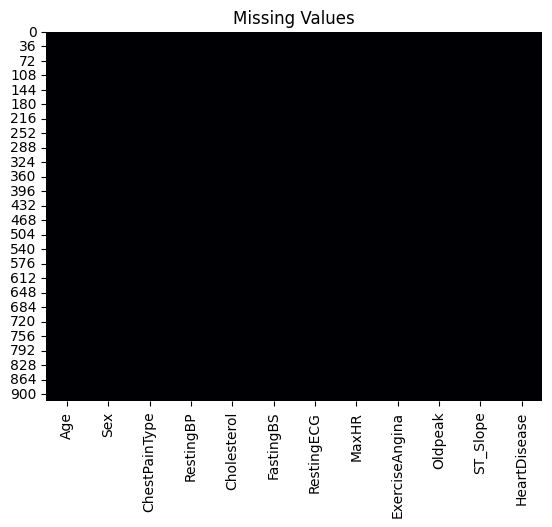

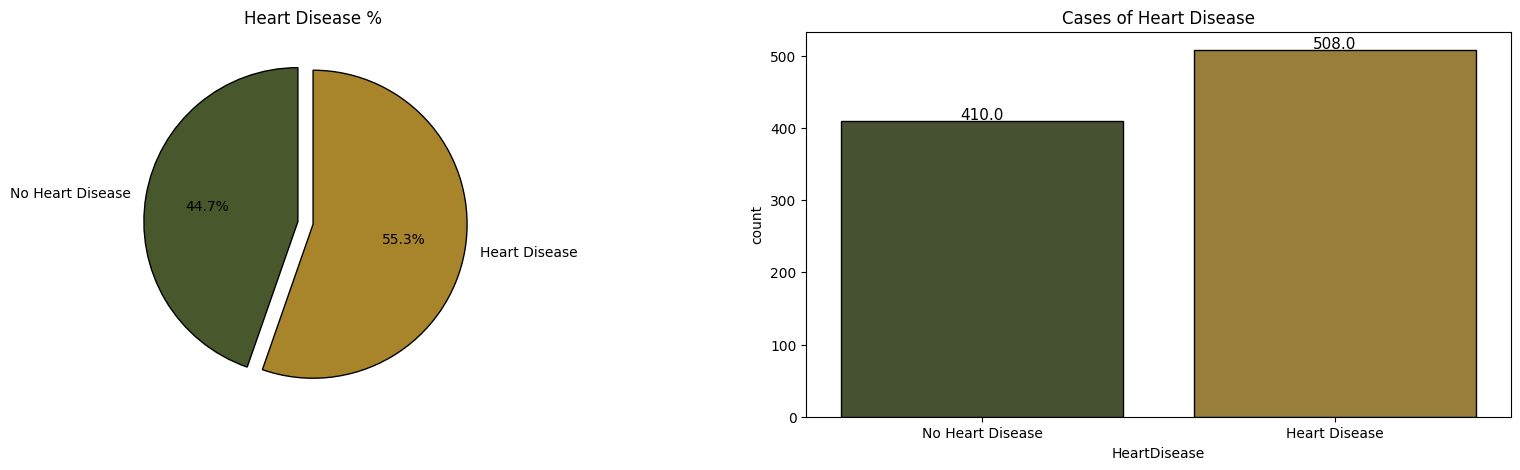

Categorical Features: Sex ChestPainType FastingBS RestingECG ExerciseAngina ST_Slope HeartDisease
Numerical Features  : Age RestingBP Cholesterol MaxHR Oldpeak


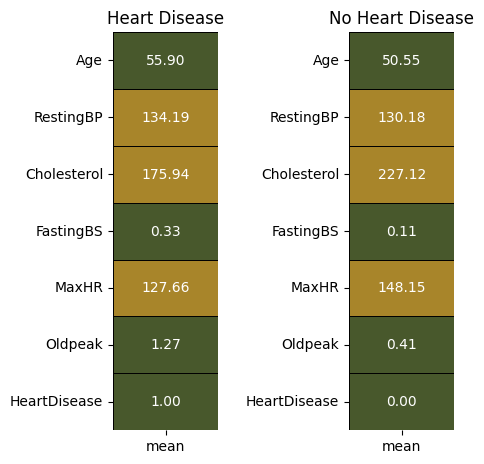

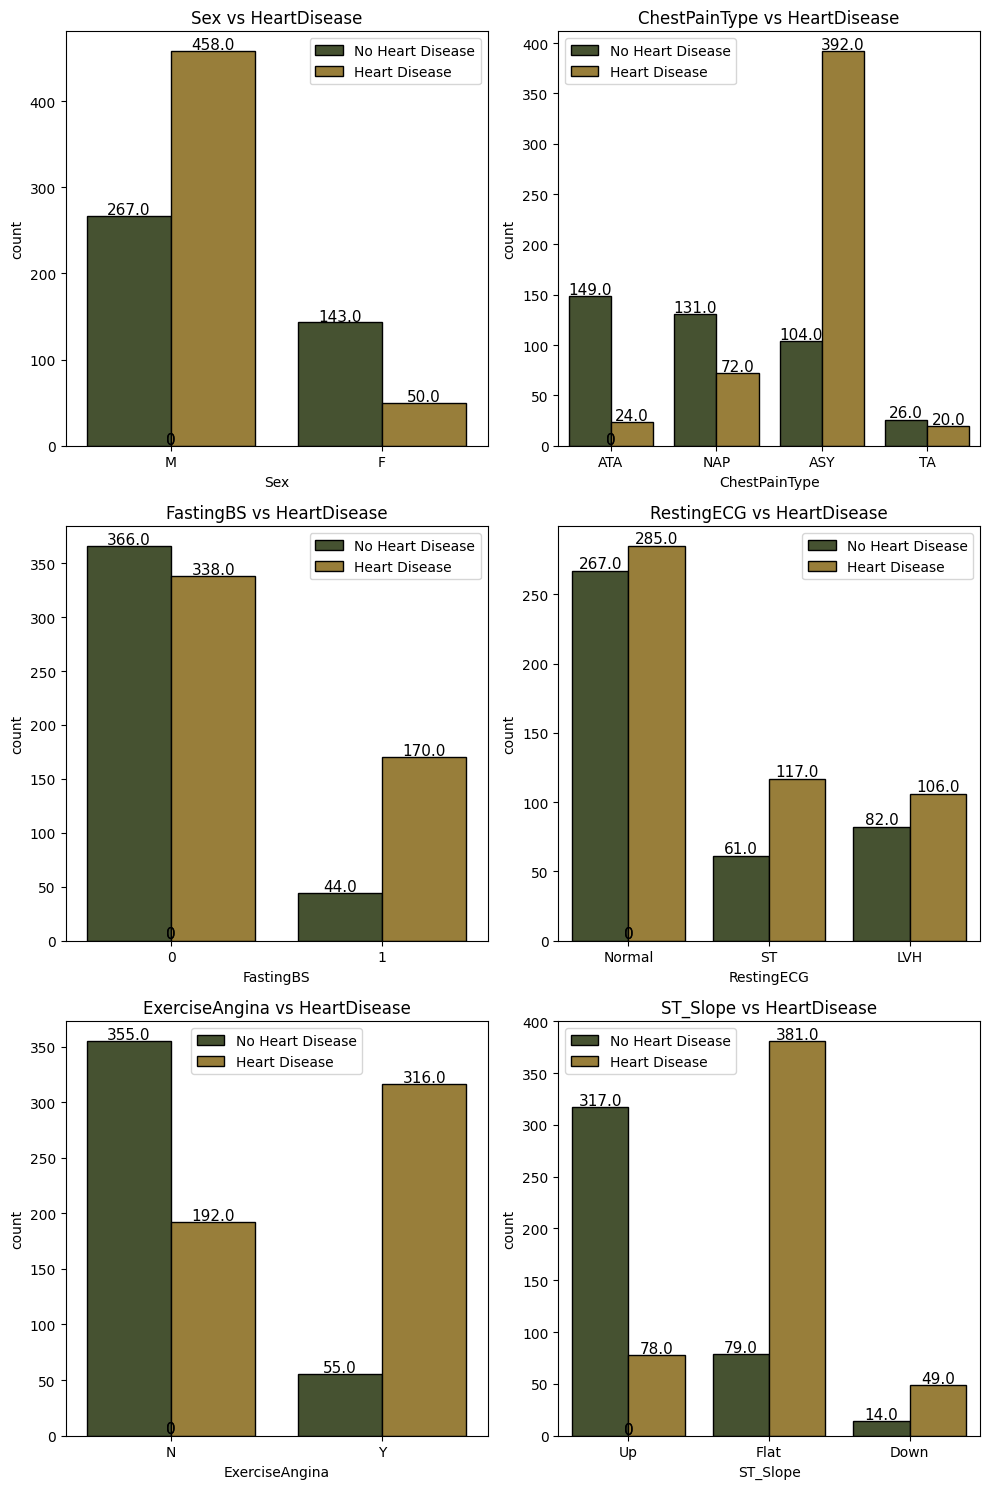

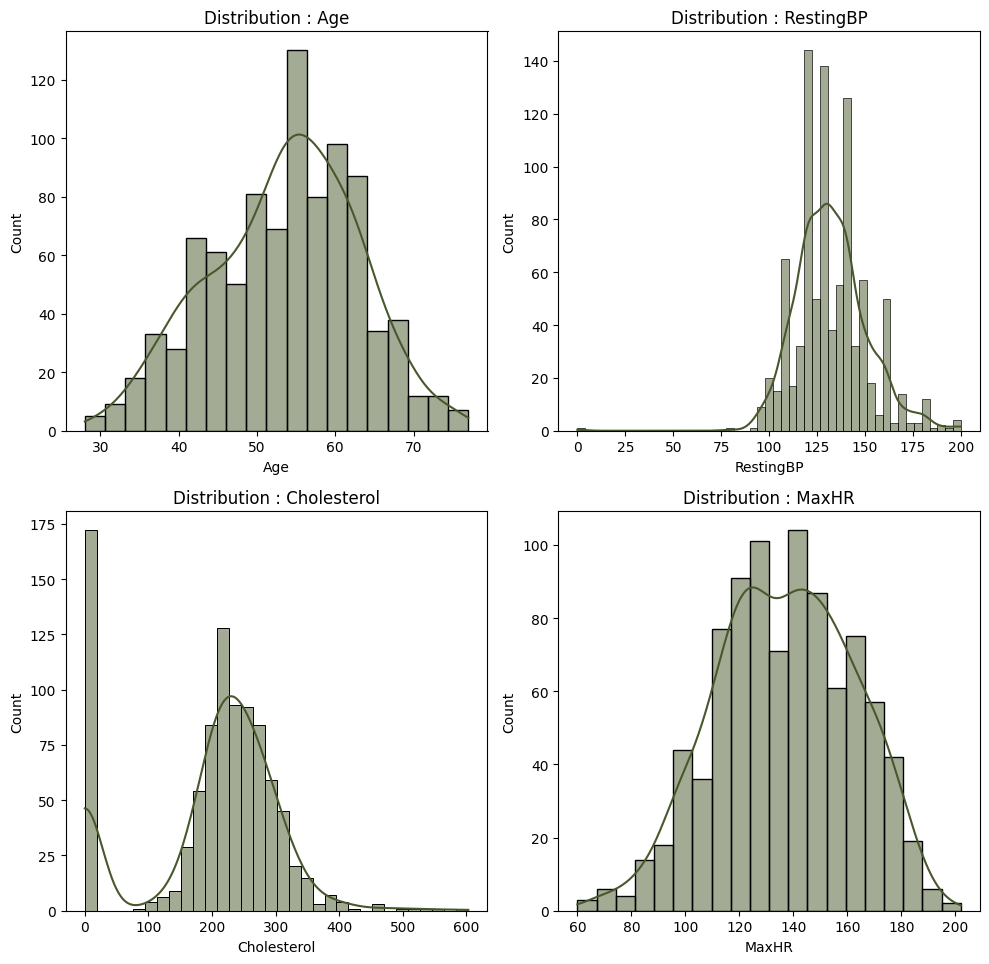

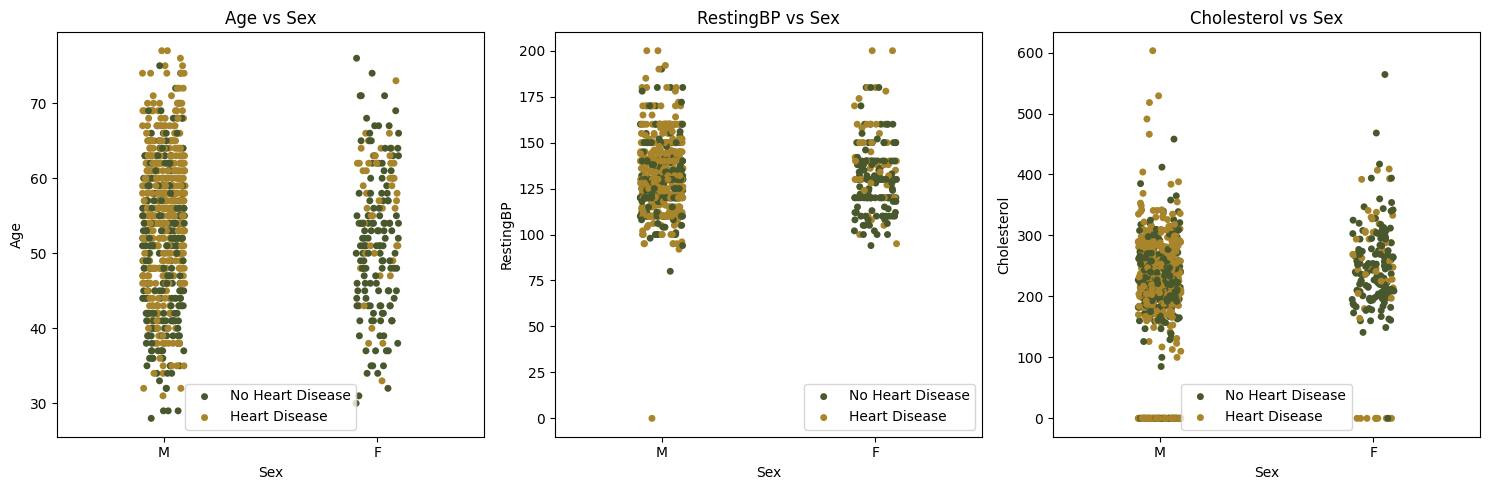

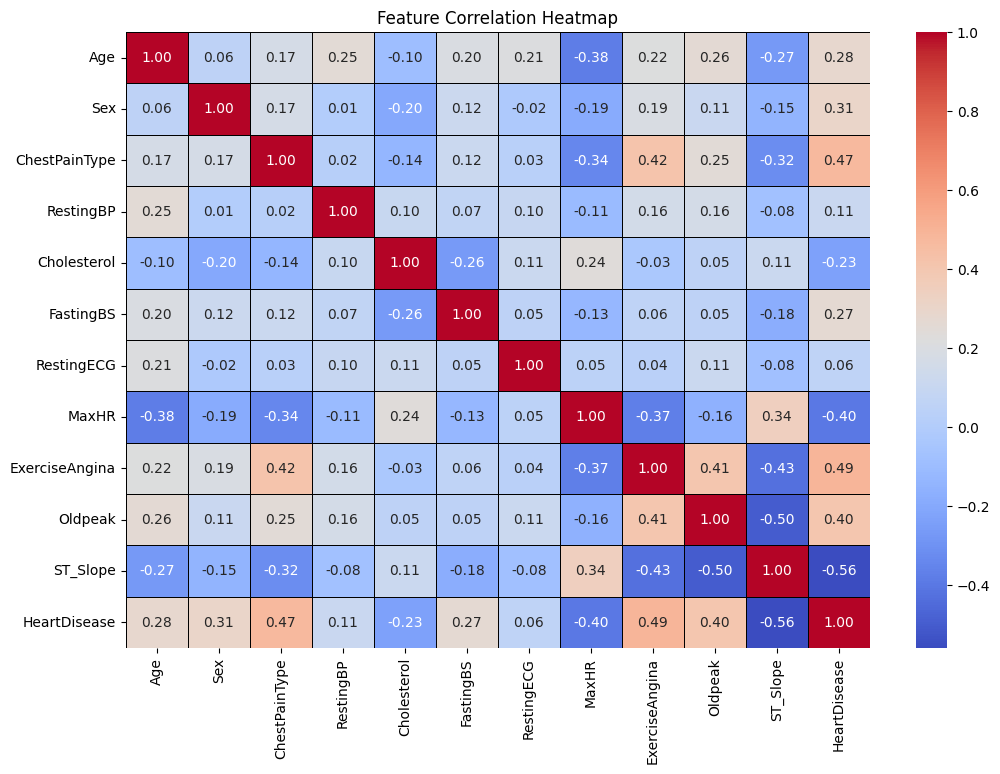

Train size: 734 | Test size: 184

Accuracy  : 0.864
F1 Score  : 0.882
Precision : 0.853
Recall    : 0.912
AUC-ROC   : 0.901

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84        82
           1       0.85      0.91      0.88       102

    accuracy                           0.86       184
   macro avg       0.87      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



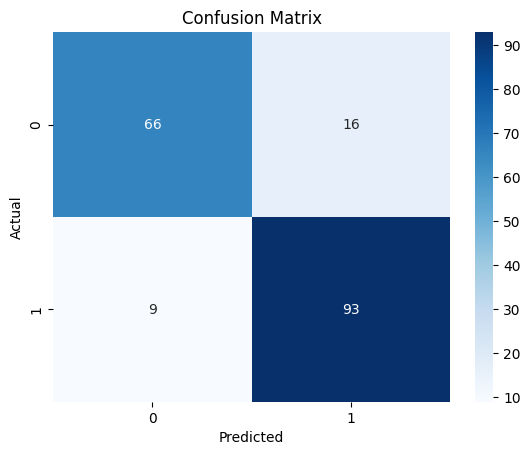


Pipeline saved as heart_disease_pipeline.joblib


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/heart.csv')

# ── Basic EDA ─────────────────────────────────────────────────────────────────
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.nunique())

# ── Missing Values ────────────────────────────────────────────────────────────
sns.heatmap(df.isnull(), cmap='magma', cbar=False)
plt.title('Missing Values')
plt.show()

# ── Class Distribution ────────────────────────────────────────────────────────
l = list(df['HeartDisease'].value_counts())
circle = [l[1] / sum(l) * 100, l[0] / sum(l) * 100]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.pie(circle, labels=['No Heart Disease', 'Heart Disease'],
        autopct='%1.1f%%', startangle=90, explode=(0.1, 0),
        colors=['#48582C', '#A8852A'],
        wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True})
plt.title('Heart Disease %')

plt.subplot(1, 2, 2)
ax = sns.countplot(x='HeartDisease', data=df,
                   palette=['#48582C', '#A8852A'], edgecolor='black')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 2, rect.get_height(),
            horizontalalignment='center', fontsize=11)
ax.set_xticklabels(['No Heart Disease', 'Heart Disease'])
plt.title('Cases of Heart Disease')
plt.show()

# ── Feature Type Separation ───────────────────────────────────────────────────
col = list(df.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(df[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features:', *categorical_features)
print('Numerical Features  :', *numerical_features)

# ── Mean Heatmap by Target ────────────────────────────────────────────────────
colors = ['#48582C', '#A8852A']
yes = df[df['HeartDisease'] == 1].describe().T
no  = df[df['HeartDisease'] == 0].describe().T

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(5, 5))
plt.subplot(1, 2, 1)
sns.heatmap(yes[['mean']], annot=True, cmap=colors,
            linewidths=0.4, linecolor='black', cbar=False, fmt='.2f')
plt.title('Heart Disease')

plt.subplot(1, 2, 2)
sns.heatmap(no[['mean']], annot=True, cmap=colors,
            linewidths=0.4, linecolor='black', cbar=False, fmt='.2f')
plt.title('No Heart Disease')
fig.tight_layout(pad=2)
plt.show()

# ── Categorical vs Target ─────────────────────────────────────────────────────
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 15))
for i in range(len(categorical_features) - 1):
    plt.subplot(3, 2, i + 1)
    ax2 = sns.countplot(x=categorical_features[i], data=df,
                        hue='HeartDisease', palette=colors, edgecolor='black')
    for rect in ax2.patches:
        ax2.text(rect.get_x() + rect.get_width() / 2,
                 rect.get_height() + 2, rect.get_height(),
                 horizontalalignment='center', fontsize=11)
    plt.legend(['No Heart Disease', 'Heart Disease'])
    plt.title(categorical_features[i] + ' vs HeartDisease')
plt.tight_layout()
plt.show()

# ── Numerical Distributions ───────────────────────────────────────────────────
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 9.75))
for i in range(len(numerical_features) - 1):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[numerical_features[i]], color=colors[0], kde=True)
    plt.title('Distribution : ' + numerical_features[i])
plt.tight_layout()
plt.show()

# ── Strip Plots — Numerical vs Sex ───────────────────────────────────────────
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    sns.stripplot(x='Sex', y=numerical_features[i], data=df,
                  hue='HeartDisease', palette=colors)
    plt.legend(['No Heart Disease', 'Heart Disease'])
    plt.title(numerical_features[i] + ' vs Sex')
plt.tight_layout()
plt.show()

# ── Correlation Heatmap ───────────────────────────────────────────────────────
df_encoded = df.copy(deep=True)
df_encoded['Sex']            = df_encoded['Sex'].map({"M": 1, "F": 0})
df_encoded['ExerciseAngina'] = df_encoded['ExerciseAngina'].map({"Y": 1, "N": 0})
df_encoded['ChestPainType']  = df_encoded['ChestPainType'].map({"TA": 0, "ATA": 1, "NAP": 2, "ASY": 3})
df_encoded['RestingECG']     = df_encoded['RestingECG'].map({"Normal": 0, "ST": 1, "LVH": 2})
df_encoded['ST_Slope']       = df_encoded['ST_Slope'].map({"Up": 2, "Flat": 1, "Down": 0})

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='black')
plt.title('Feature Correlation Heatmap')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# MODEL TRAINING
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, roc_auc_score,
                              precision_score, recall_score,
                              classification_report, confusion_matrix)
import joblib

# ── FIXED Encoding — matches Gradio app exactly ───────────────────────────────
df1 = df.copy(deep=True)
df1['Sex']            = df1['Sex'].map({"M": 1, "F": 0})
df1['ExerciseAngina'] = df1['ExerciseAngina'].map({"Y": 1, "N": 0})
df1['ChestPainType']  = df1['ChestPainType'].map({"TA": 0, "ATA": 1, "NAP": 2, "ASY": 3})
df1['RestingECG']     = df1['RestingECG'].map({"Normal": 0, "ST": 1, "LVH": 2})
df1['ST_Slope']       = df1['ST_Slope'].map({"Up": 2, "Flat": 1, "Down": 0})
df1['Cholesterol'] = df1['Cholesterol'].replace(0, df1['Cholesterol'].median())

# ── Features & Target ─────────────────────────────────────────────────────────
cols = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol',
        'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

x = df1[cols]
y = df1['HeartDisease']

# ── Train/Test Split — fixed & stratified ────────────────────────────────────
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(x_train)} | Test size: {len(x_test)}")

# ── Pipeline ──────────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
pipeline.fit(x_train, y_train)

# ── Metrics ───────────────────────────────────────────────────────────────────
y_pred      = pipeline.predict(x_test)
y_pred_prob = pipeline.predict_proba(x_test)[:, 1]

print("\n" + "=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.3f}")
print(f"Precision : {precision_score(y_test, y_pred):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_pred_prob):.3f}")
print("=" * 40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ── Save Pipeline ─────────────────────────────────────────────────────────────
joblib.dump(pipeline, 'heart_disease_pipeline.joblib')
print("\nPipeline saved as heart_disease_pipeline.joblib")

In [ ]:
# ── Test with a single patient ─────────────────────────────────────────────
# Column order: Age, Sex, ChestPainType, RestingBP, Cholesterol,
#               FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope

# Encoding reminder:
# Sex           → M=1, F=0
# ChestPainType → TA=0, ATA=1, NAP=2, ASY=3
# RestingECG    → Normal=0, ST=1, LVH=2
# ExerciseAngina→ Y=1, N=0
# ST_Slope      → Up=2, Flat=1, Down=0

patient = [[52, 1, 3, 135, 240, 0, 0, 150, 0, 1.5, 1]]
#           Age Sex CP  BP  Chol FBS ECG  HR  Ang  Old Slp

prob = pipeline.predict_proba(patient)[0][1] * 100
pred = pipeline.predict(patient)[0]

print(f"Prediction  : {'Heart Disease' if pred == 1 else 'Healthy'}")
print(f"Probability : {prob:.2f}%")

Prediction  : Heart Disease
Probability : 74.63%


In [ ]:
# Older male, asymptomatic CP, high BP, exercise angina, downsloping ST
high_risk = [[65, 1, 3, 155, 260, 1, 1, 105, 1, 3.0, 0]]
prob = pipeline.predict_proba(high_risk)[0][1] * 100
print(f"High Risk Patient: {prob:.2f}%")  # should be very high

High Risk Patient: 99.81%


In [ ]:
# Young female, typical angina, normal BP, no angina, upsloping ST
low_risk = [[35, 0, 0, 120, 180, 0, 0, 170, 0, 0.5, 2]]
prob = pipeline.predict_proba(low_risk)[0][1] * 100
print(f"Low Risk Patient: {prob:.2f}%")  # should be very low

Low Risk Patient: 0.82%


In [ ]:
# Check which patients the model got wrong
results = x_test.copy()
results['Actual']      = y_test.values
results['Predicted']   = y_pred
results['Probability'] = (y_pred_prob * 100).round(1)
results['Correct']     = results['Actual'] == results['Predicted']

print(f"\nCorrect   : {results['Correct'].sum()}")
print(f"Wrong     : {(~results['Correct']).sum()}")
print(f"\nFalse Negatives (missed sick patients):")
print(results[(results['Actual']==1) & (results['Predicted']==0)])
print(f"\nFalse Positives (healthy flagged as sick):")
print(results[(results['Actual']==0) & (results['Predicted']==1)])


Correct   : 159
Wrong     : 25

False Negatives (missed sick patients):
     Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
763   58    1              2        132          224          0           2   
383   38    0              3        110          223          0           0   
1     49    0              2        160          180          0           0   
379   50    1              3        120          223          0           1   
889   59    1              0        134          204          0           0   
440   52    1              2        128          223          0           1   
759   54    1              1        192          283          0           2   
684   47    1              2        108          243          0           0   
492   49    1              0        130          223          0           1   

     MaxHR  ExerciseAngina  Oldpeak  ST_Slope  Actual  Predicted  Probability  \
763    173               0      3.2         2       1  

# Xboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    ))
])

pipeline_xgb.fit(x_train, y_train)

y_pred_xgb      = pipeline_xgb.predict(x_test)
y_pred_prob_xgb = pipeline_xgb.predict_proba(x_test)[:, 1]

print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_xgb):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb):.3f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_pred_prob_xgb):.3f}")
print("=" * 40)

Accuracy  : 0.864
F1 Score  : 0.874
Precision : 0.897
Recall    : 0.853
AUC-ROC   : 0.925


In [ ]:
# Instead of default 50% threshold
threshold = 0.35
y_pred_adjusted = (y_pred_prob >= threshold).astype(int)

print("=== Adjusted Threshold (35%) ===")
print(f"F1 Score  : {f1_score(y_test, y_pred_adjusted):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_adjusted):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_adjusted):.3f}")
print(classification_report(y_test, y_pred_adjusted))

=== Adjusted Threshold (35%) ===
F1 Score  : 0.880
Recall    : 0.931
Precision : 0.833
              precision    recall  f1-score   support

           0       0.90      0.77      0.83        82
           1       0.83      0.93      0.88       102

    accuracy                           0.86       184
   macro avg       0.87      0.85      0.85       184
weighted avg       0.86      0.86      0.86       184



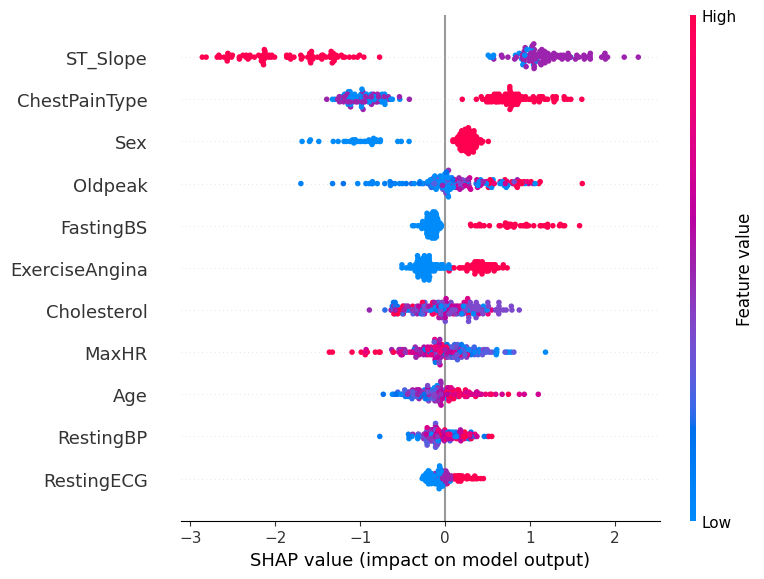

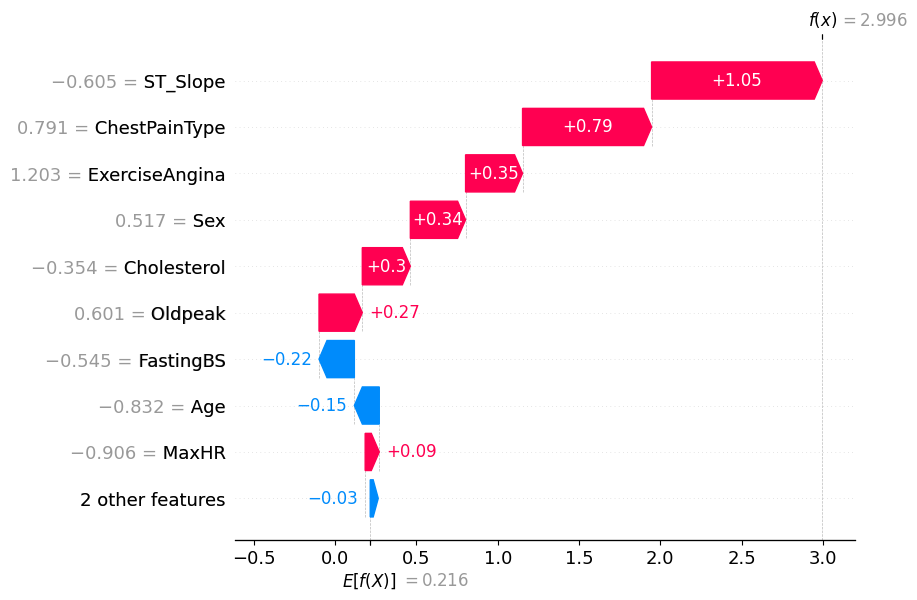

In [ ]:
# pip install shap
import shap

# Use XGBoost model
xgb_model = pipeline_xgb.named_steps['model']
scaler     = pipeline_xgb.named_steps['scaler']

x_test_scaled = scaler.transform(x_test)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_test_scaled)

# Summary plot — shows which features matter most overall
shap.summary_plot(shap_values, x_test_scaled, feature_names=cols)

# Single patient explanation
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[0],
        base_values   = explainer.expected_value,
        data          = x_test_scaled[0],
        feature_names = cols
    )
)

In [ ]:
results = x_test.copy()
results['Actual']    = y_test.values
results['Predicted'] = y_pred
results['Correct']   = results['Actual'] == results['Predicted']

# Performance by Sex
print("=== Accuracy by Sex ===")
for sex, label in [(1, 'Male'), (0, 'Female')]:
    mask = results['Sex'] == sex
    acc  = results[mask]['Correct'].mean()
    n    = mask.sum()
    print(f"{label:8s} (n={n:3d}): {acc:.3f}")

# Performance by Age group
results['AgeGroup'] = pd.cut(results['Age'],
                              bins=[0, 45, 55, 65, 100],
                              labels=['<45', '45-55', '55-65', '65+'])
print("\n=== Accuracy by Age Group ===")
print(results.groupby('AgeGroup')['Correct'].agg(['mean', 'count']))

# Performance by ExerciseAngina
print("\n=== Accuracy by Exercise Angina ===")
for val, label in [(1, 'Yes'), (0, 'No')]:
    mask = results['ExerciseAngina'] == val
    acc  = results[mask]['Correct'].mean()
    fn   = ((results['Actual']==1) & (results['Predicted']==0) & mask).sum()
    print(f"Angina={label:3s} (n={mask.sum():3d}): Accuracy={acc:.3f} | False Negatives={fn}")

=== Accuracy by Sex ===
Male     (n=146): 0.863
Female   (n= 38): 0.868

=== Accuracy by Age Group ===
              mean  count
AgeGroup                 
<45       0.847826     46
45-55     0.816901     71
55-65     0.905660     53
65+       1.000000     14

=== Accuracy by Exercise Angina ===
Angina=Yes (n= 71): Accuracy=0.873 | False Negatives=1
Angina=No  (n=113): Accuracy=0.858 | False Negatives=8


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators' : [50, 100, 200],
    'model__max_depth'    : [3, 4, 5],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__subsample'    : [0.8, 1.0],
}

grid_search = GridSearchCV(
    pipeline_xgb, param_grid,
    cv=5, scoring='recall',   # optimize for recall — catch sick patients
    n_jobs=-1, verbose=1
)
grid_search.fit(x_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best recall:", grid_search.best_score_)


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 50, 'model__subsample': 1.0}
Best recall: 0.889039445950015


# xboost with SHAP

In [ ]:
!pip install shap

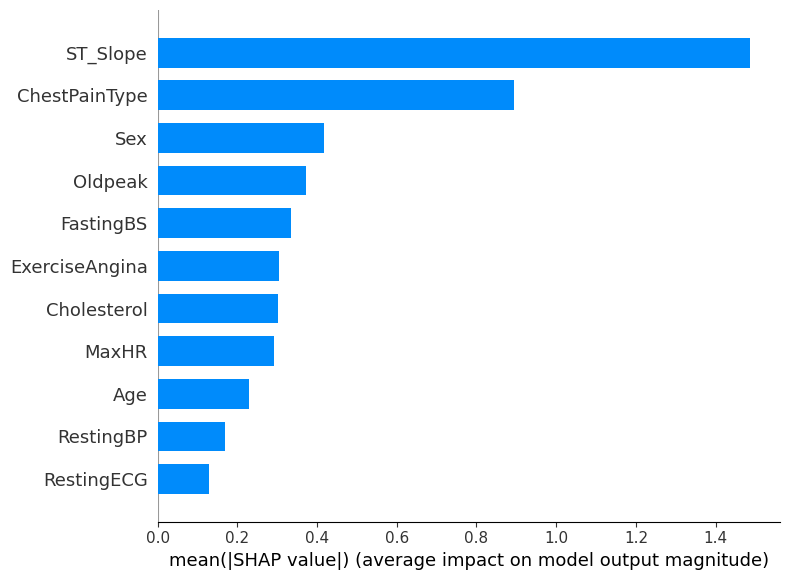

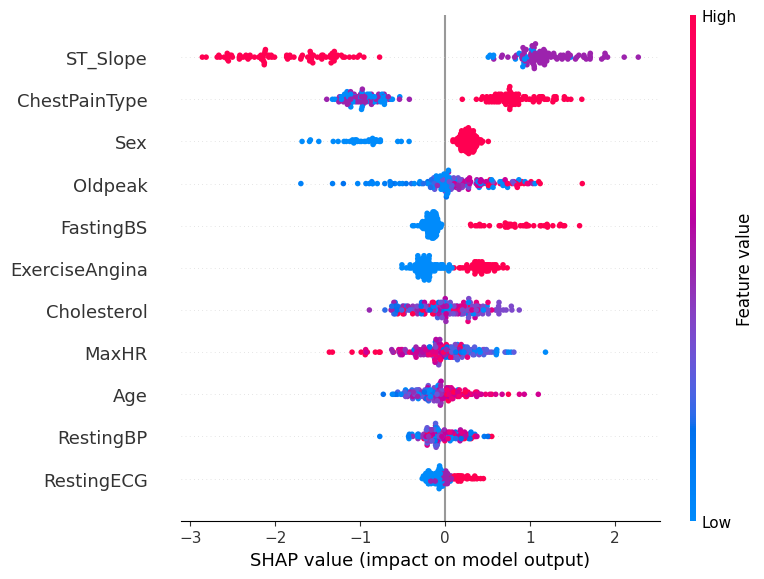

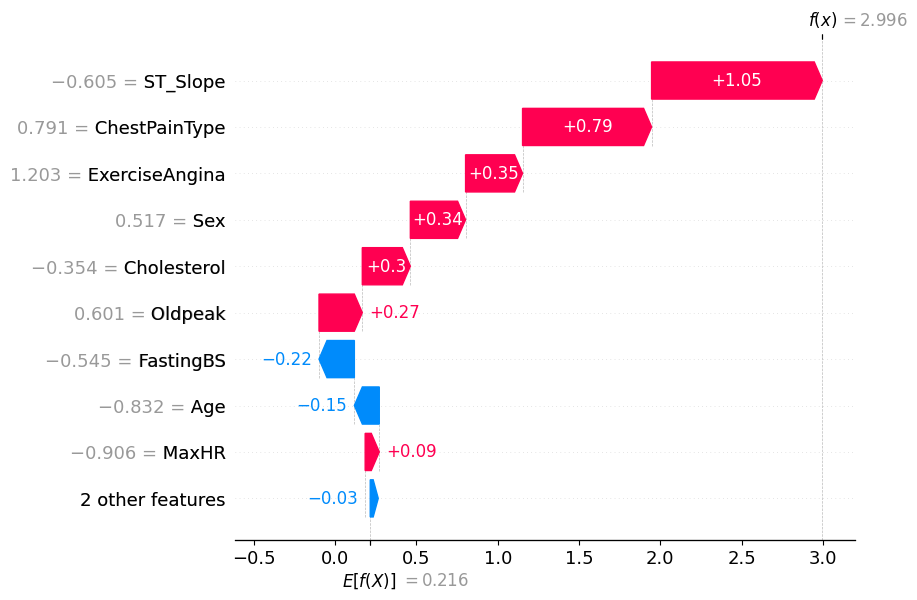

Computing interaction values — this takes a minute...


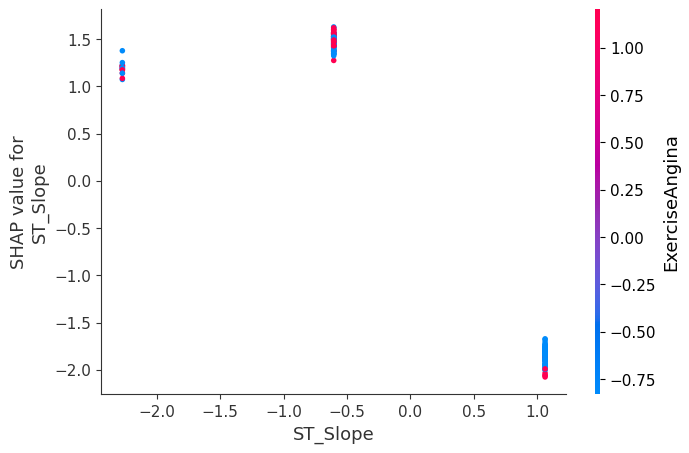

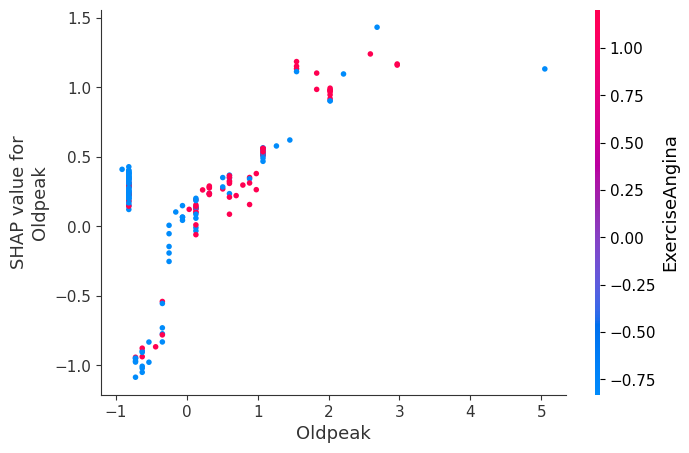


Top Feature Interactions:
Oldpeak        ST_Slope         0.291877
ST_Slope       Oldpeak          0.291877
Age            ST_Slope         0.116083
ST_Slope       Age              0.116083
MaxHR          ST_Slope         0.107857
ST_Slope       MaxHR            0.107857
ChestPainType  ST_Slope         0.106393
ST_Slope       ChestPainType    0.106393
ChestPainType  MaxHR            0.102581
MaxHR          ChestPainType    0.102581


In [ ]:
# pip install shap
import shap
import matplotlib.pyplot as plt

# ── Setup ─────────────────────────────────────────────────────────────────────
xgb_model     = pipeline_xgb.named_steps['model']
scaler        = pipeline_xgb.named_steps['scaler']
x_test_scaled = scaler.transform(x_test)

feature_names = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol',
                 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

# ── SHAP Explainer ────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_test_scaled)

# ── Plot 1: Summary — overall feature importance ──────────────────────────────
shap.summary_plot(
    shap_values,
    x_test_scaled,
    feature_names=feature_names,
    plot_type='bar',
    show=True
)

# ── Plot 2: Beeswarm — direction of impact ────────────────────────────────────
shap.summary_plot(
    shap_values,
    x_test_scaled,
    feature_names=feature_names,
    show=True
)

# ── Plot 3: Single patient waterfall — explain one prediction ─────────────────
# Change index to any patient you want to explain
patient_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[patient_index],
        base_values   = explainer.expected_value,
        data          = x_test_scaled[patient_index],
        feature_names = feature_names
    )
)

# ── Plot 4: SHAP Interaction Values ───────────────────────────────────────────
print("Computing interaction values — this takes a minute...")
shap_interaction = explainer.shap_interaction_values(x_test_scaled)

# Fix — get feature index manually
st_slope_idx      = feature_names.index("ST_Slope")
exercise_idx      = feature_names.index("ExerciseAngina")
oldpeak_idx       = feature_names.index("Oldpeak")

# ST_Slope vs ExerciseAngina
shap.dependence_plot(
    st_slope_idx,
    shap_interaction[:, :, st_slope_idx],   # ← fix: slice correctly
    x_test_scaled,
    feature_names=feature_names,
    interaction_index=exercise_idx,
    show=True
)

# Oldpeak vs ExerciseAngina
shap.dependence_plot(
    oldpeak_idx,
    shap_interaction[:, :, oldpeak_idx],    # ← fix: slice correctly
    x_test_scaled,
    feature_names=feature_names,
    interaction_index=exercise_idx,
    show=True
)

# ── Top interactions numerically ──────────────────────────────────────────────
import numpy as np

mean_interactions = np.abs(shap_interaction).mean(axis=0)
interaction_df = pd.DataFrame(
    mean_interactions,
    index=feature_names,
    columns=feature_names
)
np.fill_diagonal(interaction_df.values, 0)

print("\nTop Feature Interactions:")
print("=" * 40)
interactions_sorted = (
    interaction_df
    .unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(10)
)
print(interactions_sorted.to_string())